<a href="https://colab.research.google.com/github/ushak1984/DX703-HuffPost-News-Analysis-Milestone2/blob/main/Milestone_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Project Milestone Two  - Team 8 - Alex Fok , Siam Wong, Usha Priya Krishnasamy**
 **Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
# Your code here; add as many cells as you need but make it clear what the structure is.

# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.labelsize']   = 10
plt.rcParams['lines.linewidth']  = 2
plt.rcParams['lines.markersize'] = 5
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['ytick.labelsize']  = 9
plt.rcParams['xtick.labelsize']  = 9
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f0f0f0'
plt.rcParams['grid.color']       = 'white'
plt.rcParams['grid.linewidth']   = 1.5
plt.rcParams['font.family']      = 'monospace'


from sklearn.metrics import f1_score, classification_report

import torch

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
!pip install transformers torch -q
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader






In [2]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

In [3]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [4]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))


One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [5]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

In [6]:

# Data Cleaning & Normalization

def clean_text(example):
    """Combine headline + summary and apply basic cleaning."""

    headline = example.get("headline") or ""
    summary  = example.get("short_description") or ""

    # Concatenate
    text = headline + " [SEP] " + summary

    # Basic cleaning
    text = text.strip().lower()

    return {
        "text": text,
        "category": example.get("category")
    }

# Apply cleaning
huff_clean = huff_all.map(clean_text)

Map:   0%|          | 0/200853 [00:00<?, ? examples/s]

In [7]:
# Remove empty or very short samples
def filter_short(example):
    return len(example["text"].strip()) > 20  # we can adjust this threshold if we want to

huff_clean = huff_clean.filter(filter_short)

print("After removing short / empty samples:", len(huff_clean))

Filter:   0%|          | 0/200853 [00:00<?, ? examples/s]

After removing short / empty samples: 200674


In [8]:
# Remove Duplicates

# Convert to pandas for easier duplicate removal
df = huff_clean.to_pandas()

before = len(df)
df = df.drop_duplicates(subset="text")
after = len(df)

print(f"Removed duplicates: {before - after}")

# Convert back to Hugging Face Dataset
huff_clean = DatasetDict({"data": huff_clean.from_pandas(df)})

Removed duplicates: 489


In [9]:

# Encode Labels

# Convert category to numeric labels
labels = sorted(df["category"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

df["label"] = df["category"].map(label2id)

print("# of classes:", len(label2id))

# of classes: 41


In [10]:

# Tokenization Setup

# 95th percentile of max_length
lengths = df["text"].apply(lambda x: len(x.split()))
max_length = int(np.percentile(lengths, 95))

print("Chosen max_length (95th percentile):", max_length)

# TensorFlow TextVectorization
vectorizer = layers.TextVectorization(
    max_tokens=20000,
    output_sequence_length=max_length
)

vectorizer.adapt(df["text"].values)

# Convert text
X = vectorizer(df["text"].values)
y = df["label"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Chosen max_length (95th percentile): 57
Shape of X: (200185, 57)
Shape of y: (200185,)


In [11]:
# Train / Validation / Test Split (Stratified)



# First split: train vs temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X.numpy(), y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y
)

# Second split: val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=random_seed,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 160148
Validation size: 20018
Test size: 20019


In [12]:

# Stratification Check (Proportions)

def get_proportions(counter):
    total = sum(counter.values())
    return {k: v/total for k, v in counter.items()}

def get_class_distribution(labels, name="Dataset"):
    counter = Counter(labels)
    total = sum(counter.values())

    print(f"\n{name} Distribution:")
    for k, v in sorted(counter.items()):
        print(f"{id2label[k]:25s} : {v:5d} ({v/total:.2%})")

    return counter

# Overall distribution
overall_dist = get_class_distribution(y, "Overall")

# Train / Validation / Test distributions
train_dist = get_class_distribution(y_train, "Train")
val_dist   = get_class_distribution(y_val, "Validation")
test_dist  = get_class_distribution(y_test, "Test")

overall_prop = get_proportions(overall_dist)
train_prop   = get_proportions(train_dist)
val_prop     = get_proportions(val_dist)
test_prop    = get_proportions(test_dist)

print("Checking class proportion differences (Train vs Overall):")

for k in overall_prop:
    diff = abs(overall_prop[k] - train_prop[k])
    if diff > 0.01:  # flag if >1% difference
        print(f"{id2label[k]:25s} diff: {diff:.4f}")



Overall Distribution:
ARTS                      :  1505 (0.75%)
ARTS & CULTURE            :  1338 (0.67%)
BLACK VOICES              :  4522 (2.26%)
BUSINESS                  :  5928 (2.96%)
COLLEGE                   :  1143 (0.57%)
COMEDY                    :  5094 (2.54%)
CRIME                     :  3400 (1.70%)
CULTURE & ARTS            :  1029 (0.51%)
DIVORCE                   :  3422 (1.71%)
EDUCATION                 :  1003 (0.50%)
ENTERTAINMENT             : 16048 (8.02%)
ENVIRONMENT               :  1322 (0.66%)
FIFTY                     :  1394 (0.70%)
FOOD & DRINK              :  6225 (3.11%)
GOOD NEWS                 :  1397 (0.70%)
GREEN                     :  2613 (1.31%)
HEALTHY LIVING            :  6667 (3.33%)
HOME & LIVING             :  4161 (2.08%)
IMPACT                    :  3456 (1.73%)
LATINO VOICES             :  1129 (0.56%)
MEDIA                     :  2811 (1.40%)
MONEY                     :  1706 (0.85%)
PARENTING                 :  8649 (4.32%)
PARENTS    

In [13]:
# Addressing Class Imbalance


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("Class Weights Used for Training:")
for k, v in class_weights_dict.items():
    print(f"{id2label[k]:25s} : {v:.4f}")

Class Weights Used for Training:
ARTS                      : 3.2442
ARTS & CULTURE            : 3.6505
BLACK VOICES              : 1.0796
BUSINESS                  : 0.8237
COLLEGE                   : 4.2736
COMEDY                    : 0.9585
CRIME                     : 1.4360
CULTURE & ARTS            : 4.7461
DIVORCE                   : 1.4266
EDUCATION                 : 4.8704
ENTERTAINMENT             : 0.3043
ENVIRONMENT               : 3.6919
FIFTY                     : 3.5032
FOOD & DRINK              : 0.7843
GOOD NEWS                 : 3.4938
GREEN                     : 1.8689
HEALTHY LIVING            : 0.7323
HOME & LIVING             : 1.1733
IMPACT                    : 1.4127
LATINO VOICES             : 4.3256
MEDIA                     : 1.7368
MONEY                     : 2.8616
PARENTING                 : 0.5645
PARENTS                   : 1.2531
POLITICS                  : 0.1493
QUEER VOICES              : 0.7738
RELIGION                  : 1.9175
SCIENCE               

In [14]:

# Class Distribution Analysis

def get_class_distribution(labels, name="Dataset"):
    counter = Counter(labels)
    total = sum(counter.values())

    print(f"\n{name} Distribution:")
    for k, v in sorted(counter.items()):
        print(f"{id2label[k]:25s} : {v:5d} ({v/total:.2%})")

    return counter

# Overall distribution
overall_dist = get_class_distribution(y, "Overall")

# Train / Validation / Test distributions
train_dist = get_class_distribution(y_train, "Train")
val_dist   = get_class_distribution(y_val, "Validation")
test_dist  = get_class_distribution(y_test, "Test")


Overall Distribution:
ARTS                      :  1505 (0.75%)
ARTS & CULTURE            :  1338 (0.67%)
BLACK VOICES              :  4522 (2.26%)
BUSINESS                  :  5928 (2.96%)
COLLEGE                   :  1143 (0.57%)
COMEDY                    :  5094 (2.54%)
CRIME                     :  3400 (1.70%)
CULTURE & ARTS            :  1029 (0.51%)
DIVORCE                   :  3422 (1.71%)
EDUCATION                 :  1003 (0.50%)
ENTERTAINMENT             : 16048 (8.02%)
ENVIRONMENT               :  1322 (0.66%)
FIFTY                     :  1394 (0.70%)
FOOD & DRINK              :  6225 (3.11%)
GOOD NEWS                 :  1397 (0.70%)
GREEN                     :  2613 (1.31%)
HEALTHY LIVING            :  6667 (3.33%)
HOME & LIVING             :  4161 (2.08%)
IMPACT                    :  3456 (1.73%)
LATINO VOICES             :  1129 (0.56%)
MEDIA                     :  2811 (1.40%)
MONEY                     :  1706 (0.85%)
PARENTING                 :  8649 (4.32%)
PARENTS    

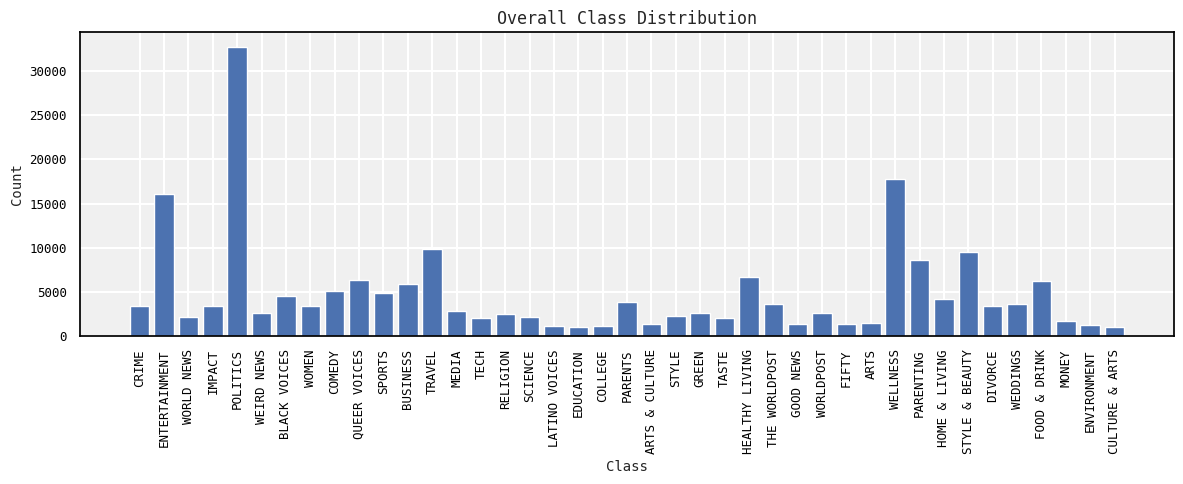

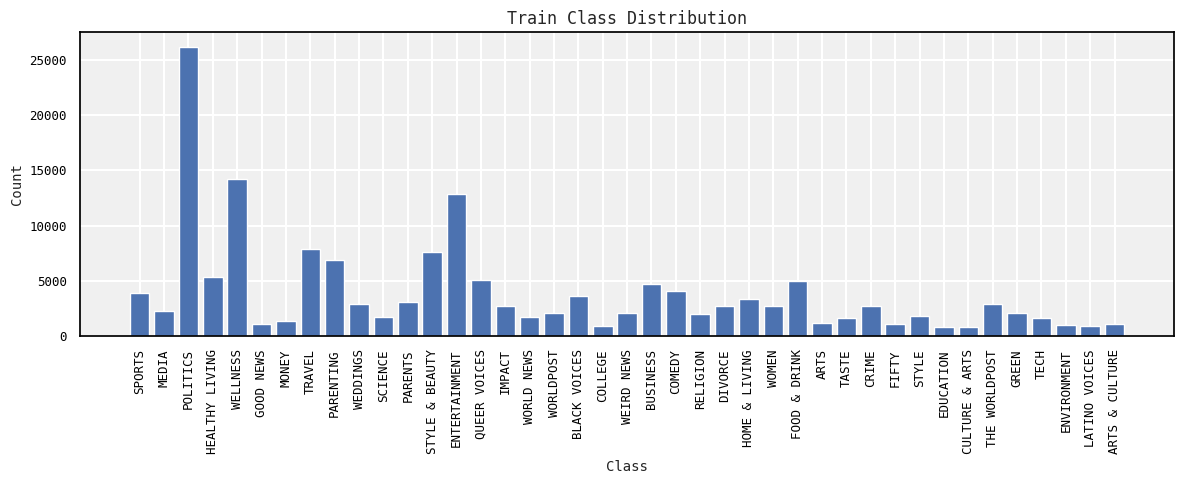

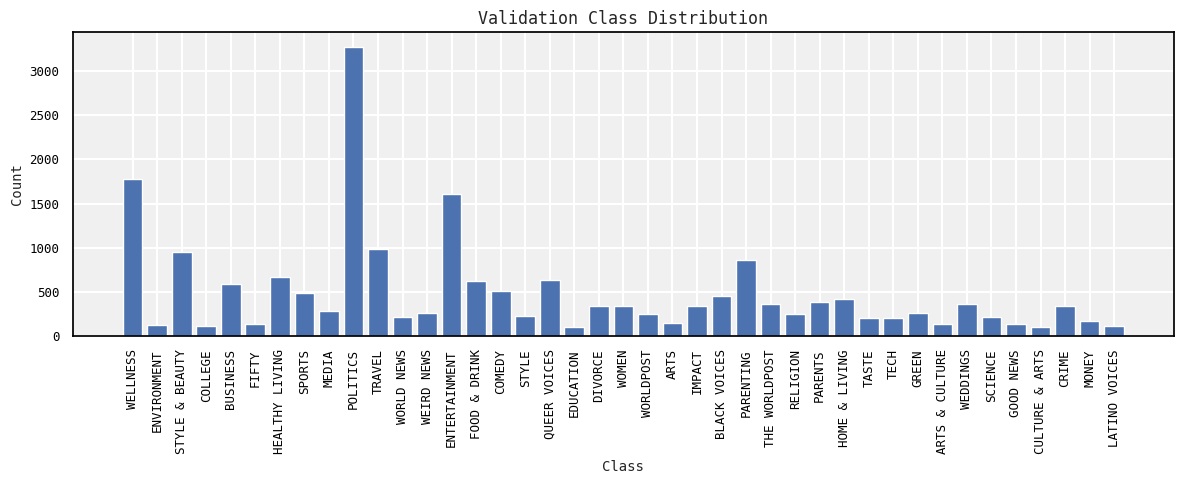

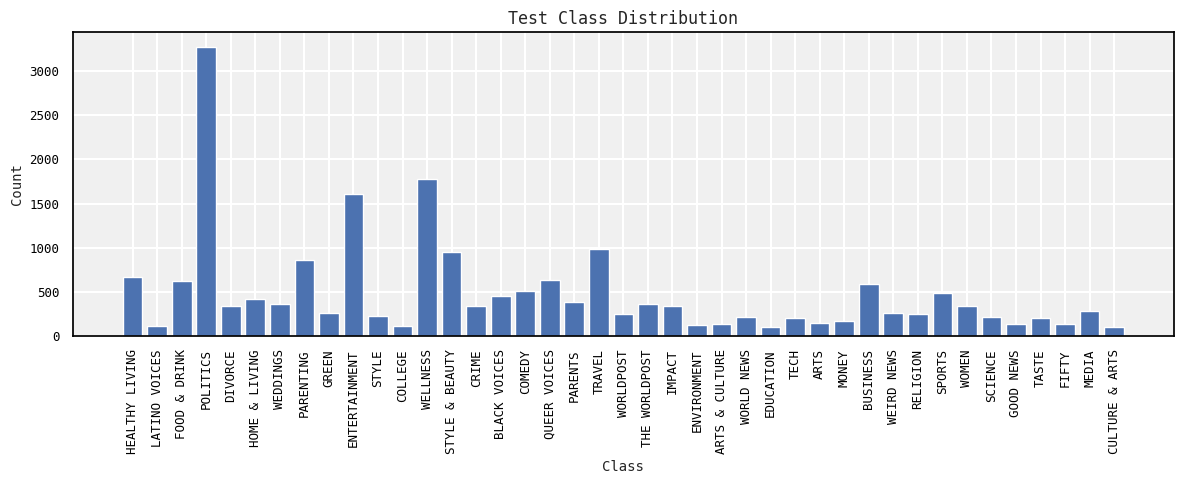

In [15]:
# Vizzes Class Distribution

def plot_distribution(counter, title):
    labels = [id2label[k] for k in counter.keys()]
    values = list(counter.values())

    plt.figure(figsize=(12, 5))
    plt.bar(labels, values)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_distribution(overall_dist, "Overall Class Distribution")
plot_distribution(train_dist, "Train Class Distribution")
plot_distribution(val_dist, "Validation Class Distribution")
plot_distribution(test_dist, "Test Class Distribution")

In [16]:
# Addressing Class Imbalance


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(3.2442265618669475), 1: np.float64(3.650512878960565), 2: np.float64(1.0796154727716432), 3: np.float64(0.8237133657713633), 4: np.float64(4.273576346266745), 5: np.float64(0.9585395780338172), 6: np.float64(1.4360473457675753), 7: np.float64(4.746110304359423), 8: np.float64(1.4266065670152683), 9: np.float64(4.870385013077064), 10: np.float64(0.3042567986047519), 11: np.float64(3.691917561897736), 12: np.float64(3.503182762769332), 13: np.float64(0.7843471446762661), 14: np.float64(3.4937824512413282), 15: np.float64(1.8689228614774187), 16: np.float64(0.7322926097652428), 17: np.float64(1.1733399761152914), 18: np.float64(1.4126758699775064), 19: np.float64(4.325635415822597), 20: np.float64(1.736793588478348), 21: np.float64(2.861574198159564), 22: np.float64(0.5645394971076463), 23: np.float64(1.253143657519347), 24: np.float64(0.14928525818795355), 25: np.float64(0.7737814541378377), 26: np.float64(1.9175497204162026), 27: np.float64(2.24227828960264

In [17]:
# Scan Processed Samples

print("Sample processed entries:")

for i in range(3):
    print("Text (tokenized):", X_train[i][:20])  # first 20 tokens
    print("Label:", y_train[i], "→", id2label[y_train[i]])
    print()
    #print("Original text:", df["text"].iloc[i])------------------------this prints shuffled value
    print("Original text:", df["text"].values[np.where(y == y_train[i])[0][i]])


Sample processed entries:
Text (tokenized): [ 5427  2550     6  6202     8  2743   558  1553     7  1427  5328 17116
     3     2    83     1 10091   337    57  2494]
Label: 28 → SPORTS

Original text: jets chairman christopher johnson won't fine players for anthem protests [sep] “i never want to put restrictions on the speech of our players."
Text (tokenized): [  178    20  2245   121  2880     8     2   432     6    51     3     2
  3406     6     2     1 13532    40   882 19119]
Label: 20 → MEDIA

Original text: new york daily news rips nfl over anthem kneeling ban [sep] "nfl dishonors the flag"
Text (tokenized): [ 1026   375     9  3176 10536     3     2   229  4960   918 11882   188
   461  4960   112     0     0     0     0     0]
Label: 24 → POLITICS

Original text: edward snowden: there's no one trump loves more than vladimir putin [sep] but don't count on robert mueller to nail him, the nsa whistleblower warns.


In [18]:
print("Original text:", df["text"].iloc[i])

Original text: hugh grant marries for the first time at age 57 [sep] the actor and his longtime girlfriend anna eberstein tied the knot in a civil ceremony.


In [19]:

# Visualize tokenized text, original text, label ID and category



def inspect_samples(n=5):
    rows = []

    for i in range(n):
        row = {
            "Original Text": df["text"].iloc[i][:100] + "...",  # truncate otherwise table is too wide
            "Tokenized (first 15)": list(X_train[i][:15]),
            "Label ID": int(y_train[i]),
            "Category": id2label[int(y_train[i])]
        }
        rows.append(row)

    return pd.DataFrame(rows)

sample_df = inspect_samples(5)
display(sample_df)

,Original Text,Tokenized (first 15),Label ID,Category
0,there were 2 mass shootings in texas last week...,"[5427, 2550, 6, 6202, 8, 2743, 558, 1553, 7, 1...",28,SPORTS
1,will smith joins diplo and nicky jam for the 2...,"[178, 20, 2245, 121, 2880, 8, 2, 432, 6, 51, 3...",20,MEDIA
2,hugh grant marries for the first time at age 5...,"[1026, 375, 9, 3176, 10536, 3, 2, 229, 4960, 9...",24,POLITICS
3,jim carrey blasts 'castrato' adam schiff and d...,"[2, 88, 857, 10, 7120, 1501, 3, 324, 14, 5, 35...",16,HEALTHY LIVING
4,julianna margulies uses donald trump poop bags...,"[2630, 460, 2658, 2266, 478, 3, 2, 183, 4550, ...",37,WELLNESS


### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).




1.1. **Your answer here:**


*   The headline and short_description fields were concatenated into a single input using a [SEP] token to preserve structure.
*   Empty or very short samples (less than 20 characters) were removed to reduce noise and improve data quality.
*  All text was stripped of leading/trailing whitespace and converted to lowercase to ensure consistency across samples.
*  Duplicate text entries were identified and removed to prevent data leakage and bias during training.
*  The categorical labels were converted into numerical IDs to make them compatible with machine learning models.
*  A TextVectorization layer was used to tokenize the text. The maximum sequence length was set using the 95th percentile of text lengths to balance coverage and efficiency.
*  Class weights were computed using compute_class_weight to address label imbalance during training.
*  The cleaned dataset was split into training (80%), validation (10%), and test (10%) sets using stratified sampling with a fixed random seed (42) to ensure reproducibility.




2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**


*   The headline and short_description fields were concatenated using a [SEP] token. This preserves both sources of information while giving the model a clear boundary between them.
*   All text was converted to lowercase and stripped of extra whitespace. This reduces vocabulary size and ensures consistency across inputs, preventing the model from treating similar words (e.g., “News” vs. “news”) as different tokens.
*  Very short or empty samples were removed, as they provide little information and can introduce noise into the model.
*  Duplicate entries were removed to avoid bias and prevent the model from overfitting to repeated samples.
*  A TensorFlow TextVectorization layer was used to convert text into integer token sequences. This step transforms raw text into a numerical format required for neural networks.
*  The maximum sequence length was set using the 95th percentile of text lengths. Sequences longer than this were truncated, and shorter ones were padded. This ensures consistent input shape while minimizing unnecessary padding.
*  The tokenizer was configured with a maximum vocabulary size (e.g., 20,000 tokens) to balance model expressiveness and computational efficiency.
*  Text categories were converted into numeric labels so they could be used as targets for classification.
*  Class weights were computed to address imbalance in category distribution, ensuring that underrepresented classes are not ignored during training.
*  A fixed random seed was used across all steps (data splitting, tokenization) to ensure consistent and reproducible results.

---------------------------------------------------------------------------------------------------------------------------------------



3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

The dataset was divided into training, validation, and test subsets to ensure reliable model training and unbiased evaluation. The data was split into 80% training, 10% validation, and 10% test.
This was implemented in two steps: (1) the dataset was split into training (80%) and a temporary set (20%) and (2) the temporary set was then evenly divided into validation (10%) and test (10%).

A fixed random seed (random_seed = 42) was used in all splitting operations. This ensures that the same data partitions are generated every time the code is run, enabling reproducibility.

Stratified splitting was applied using the label distribution (stratify = y). This ensures that each subset (train, validation, test) maintains approximately the same class distribution as the original dataset, which is especially important for handling class imbalance.

Several steps were taken to avoid data leakage:

* (1) Duplicate samples were removed before splitting, ensuring that identical entries do not appear across different subsets.
* (2) All preprocessing steps that could introduce bias (e.g., tokenization adaptation) were applied consistently without using label information from validation/test sets improperly.
* (3) The test set was kept completely separate and used only for final evaluation.

After splitting, the sizes of each subset were printed and inspected to confirm the expected proportions. Additionally, class distributions were checked to verify that stratification worked correctly.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**

The class distribution of the HuffPost dataset was analyzed by counting the number of samples per category. The dataset exhibits class imbalance, where some categories (e.g., Politics, Wellness) contain significantly more samples than others. To better understand this imbalance, label counts were computed and visualized across the full dataset as well as the training, validation, and test splits. Stratified sampling ensured that each subset maintained approximately the same class proportions as the original dataset.

Observed Imbalance:
* The dataset is not uniformly distributed across categories, with certain classes having disproportionately higher representation. This imbalance can bias the model toward majority classes.
* Handling Imbalance:
To address this, class weights were computed using compute_class_weight. These weights assign higher importance to underrepresented classes during training, helping the model learn more balanced decision boundaries.
* Verification of Stratification:
After splitting, class distributions across training, validation, and test sets were compared. The proportions were consistent, confirming that stratified sampling preserved the original distribution.



## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [20]:
# Your code here; add as many cells as you need but make it clear what the structure is.




# Ensure arrays are in the right format
X_train = np.array(X_train)
X_val   = np.array(X_val)
X_test  = np.array(X_test)

y_train = np.array(y_train).astype("int32")
y_val   = np.array(y_val).astype("int32")
y_test  = np.array(y_test).astype("int32")

num_classes = len(label2id)
vocab_size = len(vectorizer.get_vocabulary())

print("Vocab size:", vocab_size)
print("Number of classes:", num_classes)
print("Input sequence length:", max_length)

Vocab size: 20000
Number of classes: 41
Input sequence length: 57


In [21]:
# Build tf.data pipelines for efficiency
batch_size = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=random_seed, reshuffle_each_iteration=True)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [22]:
# Baseline model

baseline_model = models.Sequential([
    layers.Input(shape=(max_length,), dtype="int32"),
    layers.Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 57, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,570,921 (9.81 MB)

 Trainable params: 2,570,921 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:

# Add early stopping

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [25]:
# Class weights

class_weights_dict = {int(k): float(v) for k, v in class_weights_dict.items()}

In [26]:

# Train

start_time = time.time()

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights_dict,
    verbose=1
)

runtime_sec = time.time() - start_time
epochs_trained = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
best_val_loss = float(np.min(history.history["val_loss"]))
best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])


print("Epochs trained:", epochs_trained)
print("Runtime:", format_hms(runtime_sec))
print("Best epoch (min val loss):", best_epoch)
print("Validation loss at best epoch:", round(best_val_loss, 4))
print("Validation accuracy at best epoch:", round(best_val_acc, 4))

Epoch 1/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3253 - loss: 2.7957 - val_accuracy: 0.4942 - val_loss: 1.9888
Epoch 2/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4904 - loss: 1.8854 - val_accuracy: 0.5296 - val_loss: 1.7639
Epoch 3/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5390 - loss: 1.5780 - val_accuracy: 0.5310 - val_loss: 1.7101
Epoch 4/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5662 - loss: 1.3947 - val_accuracy: 0.5309 - val_loss: 1.7141
Epoch 5/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5872 - loss: 1.2566 - val_accuracy: 0.5285 - val_loss: 1.7110
Epoch 6/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6017 - loss: 1.1524 - val_accuracy: 0.5329 - val_loss: 1.7200
Epoch 7/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6130 - loss: 1.0731 - val_accuracy: 0.5286 - val_loss: 1.7640
Epoch 8/30
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6265 - loss: 0.9998 - 

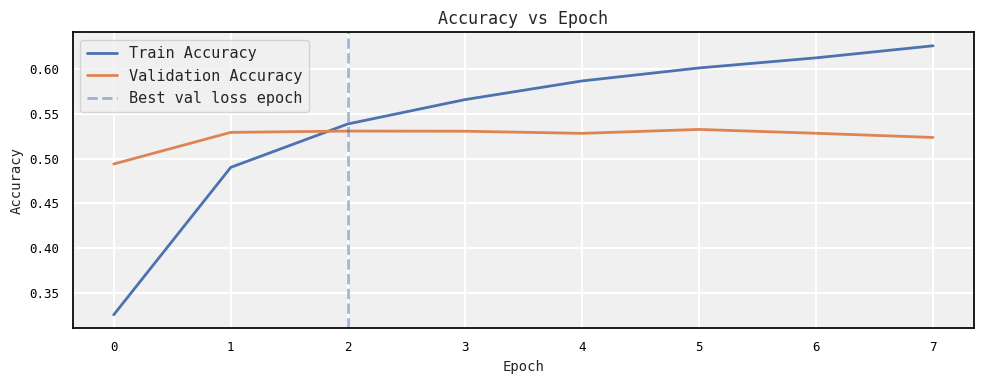

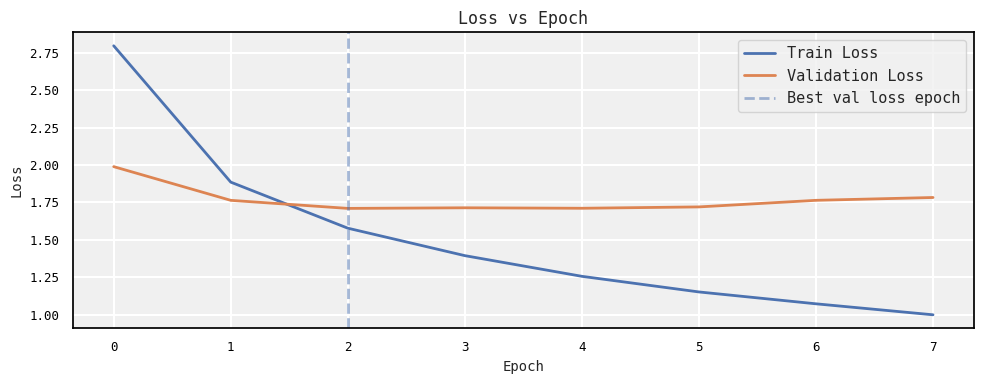

In [27]:

# Plot training history

plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.axvline(best_epoch - 1, linestyle="--", alpha=0.5, label="Best val loss epoch")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch - 1, linestyle="--", alpha=0.5, label="Best val loss epoch")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Evaluate on test data

test_loss, test_acc = baseline_model.evaluate(test_ds, verbose=0)
print("Test results")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

Test results
Test loss: 1.708
Test accuracy: 0.5331


In [29]:
# Macro F1 on test
y_prob = baseline_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Test macro F1:", round(macro_f1, 4))

Test macro F1: 0.4557


In [30]:
# Report
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=[id2label[i] for i in range(num_classes)]))

Classification report:
                precision    recall  f1-score   support

          ARTS       0.24      0.27      0.25       150
ARTS & CULTURE       0.18      0.38      0.24       134
  BLACK VOICES       0.41      0.45      0.43       452
      BUSINESS       0.44      0.39      0.41       593
       COLLEGE       0.33      0.53      0.40       114
        COMEDY       0.43      0.46      0.45       510
         CRIME       0.46      0.67      0.55       340
CULTURE & ARTS       0.24      0.57      0.34       103
       DIVORCE       0.76      0.75      0.75       342
     EDUCATION       0.25      0.60      0.36       100
 ENTERTAINMENT       0.77      0.46      0.57      1605
   ENVIRONMENT       0.25      0.59      0.35       132
         FIFTY       0.10      0.32      0.16       139
  FOOD & DRINK       0.66      0.56      0.61       623
     GOOD NEWS       0.21      0.33      0.26       139
         GREEN       0.35      0.40      0.38       262
HEALTHY LIVING       0.3

In [31]:
print("Train accuracy final:", history.history["accuracy"][-1])
print("Val accuracy final:", history.history["val_accuracy"][-1])
print("Best val accuracy:", max(history.history["val_accuracy"]))

Train accuracy final: 0.6265454292297363
Val accuracy final: 0.5238785147666931
Best val accuracy: 0.5328704118728638


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

This baseline model's architecture consists of Embedding layer, Global Average Pooling, Dense layer, and Softmax output layer.


*   Embedding turns tokenIDs into dense vectors
*   Global Average Pooling compresses the sequence into fixed-sized representation
*  Dense layers learn class-specific patterns
*  Softmax output predicts one of the category values



Why this structure suits our dataset -Since this dataset is pretty large, a simple architecture ensures fast training and iteration, making it an ideal baseline model. Compared to more complex models, this architecture has fewer parameters, thus reducing the risk of overfitting. This is especially important for a baseline model. The baseline model has a strong semantic understanding due to the embedding layer being able to capture word-level meaning, which is important for distinguishing between categories (ie politics vs entertainment). Headlines and summaries vary in length and Global Average Pooling handles this variability naturally.

Overall, this is a good baseline model becuase it's simple, fast to train, easy to interpret and good text classification performance for a baseline in that it's a reliable reference point for evaluationg more advanced models down the line.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

The training results showed that accuracy kept going up and loss kept going down during training, which means the model was learning well from the data. But for validation, loss went down at first and hit its lowest point at epoch 3, then started to go up. Validation accuracy also improved at first and peaked around epoch 6, but then stopped getting better.

By the end, training accuracy (62.6%) was much higher than validation accuracy (53.28%), and training loss was much lower than validation loss. This big gap shows that the model started to overfit the training data after about epoch 3. The early stopping feature worked correctly by going back to the weights from the best validation loss.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**


These results show that it's hard to classify this dataset with a simple model. Since there are 41 categories, getting about 53% accuracy is much better than random guessing, which would be around 2.4%. Still, the model struggles to clearly separate all the categories.

The macro F1 score (0.4557) is lower than the accuracy (0.5328), which means the model has more trouble with categories that have less data. This shows that class imbalance is still an issue, even after using class weights to try to fix it.

There are a few reasons why this task is difficult. First, some categories may use similar words or talk about similar topics, which makes them harder to separate. Second, the text (like headlines) is usually short, so there isn’t always enough information to clearly decide the category. Third, some categories have fewer examples, so the model doesn’t learn them as well.

Overall, this baseline is a good starting point, but it shows that we will probably need more advanced models or techniques to improve performance.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

The baseline model has a few main limitations:

* The model does better on the training data (62.6%) than on the validation data (53.3%). Also, the validation loss starts going up after a few epochs. This means the model is memorizing the training data instead of learning patterns that work on new data.
* The model structure is pretty simple. It might not be strong enough to tell the difference between 41 different text categories, especially since the inputs are short.
* The macro F1 score (0.4557) is lower than the accuracy, which means the model isn’t doing well on categories that don’t show up as often. Using class weights helped a little, but not enough.
* GlobalAveragePooling just averages everything, so it ignores the order of words. This can be a problem because word order can change the meaning of a sentence.

Based on these limitations, here are some things to try next:
* Instead of GlobalAveragePooling, try using a Bidirectional GRU or LSTM. This can help the model understand the order of words better and learn more from the text.
* Increase dropout and maybe add L2 regularization so the model doesn’t memorize the training data as much.
* Instead of starting from scratch, try using pre-trained embeddings like Word2Vec or GloVe, or even models like BERT. These already understand language pretty well, so they could help improve performance.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [32]:
# Define the input layer
input_layer = Input(shape=(None,), dtype="int64")

# Get vocabulary size from the adapted vectorizer
vocabulary_size = len(vectorizer.get_vocabulary())

# Embedding layer
x = layers.Embedding(vocabulary_size, 128, input_length=max_length)(input_layer)

# Global Average Pooling
x = layers.GlobalAveragePooling1D()(x)

# Custom Model Architecture
# Adding a Dense layer, Batch Normalization, Dropout, and another Dense layer
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)  # Added Batch Normalization
x = layers.Dropout(0.3)(x)          # Added Dropout
x = layers.Dense(64, activation='relu')(x) # Added another Dense layer
x = layers.Dropout(0.3)(x)          # Added another Dropout layer

# Output layer
output_layer = layers.Dense(len(label2id), activation='softmax')(x)

custom_model = models.Model(inputs=input_layer, outputs=output_layer)

custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,945 (9.87 MB)

 Trainable params: 2,587,689 (9.87 MB)

 Non-trainable params: 256 (1.00 KB)

In [33]:
# Compile the custom model
custom_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Custom model compiled successfully!")

Custom model compiled successfully!


In [34]:
print("Training Custom Model...")

# Callbacks for training
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()
history_custom = custom_model.fit(
    X_train,
    y_train,
    epochs=50, # Set a reasonably high number of epochs, EarlyStopping will stop it
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
    verbose=1
)
end_time = time.time()

training_time_custom = end_time - start_time
print(f"\nCustom model training complete in {format_hms(training_time_custom)}")

Training Custom Model...
Epoch 1/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.3242 - loss: 2.5074 - val_accuracy: 0.4515 - val_loss: 1.9797
Epoch 2/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.4613 - loss: 1.8329 - val_accuracy: 0.4552 - val_loss: 1.9517
Epoch 3/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.5042 - loss: 1.5812 - val_accuracy: 0.4696 - val_loss: 1.9619
Epoch 4/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.5299 - loss: 1.4123 - val_accuracy: 0.4835 - val_loss: 1.9162
Epoch 5/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.5502 - loss: 1.2946 - val_accuracy: 0.4925 - val_loss: 1.9475
Epoch 6/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.5648 - loss: 1.2147 - val_accuracy: 0.4883 - val_loss: 1.9839
Epoch 7/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.5785 - loss: 1.1328 - val_accuracy: 0.5009 - val_loss: 1.9382
Epoch 8/50
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - a

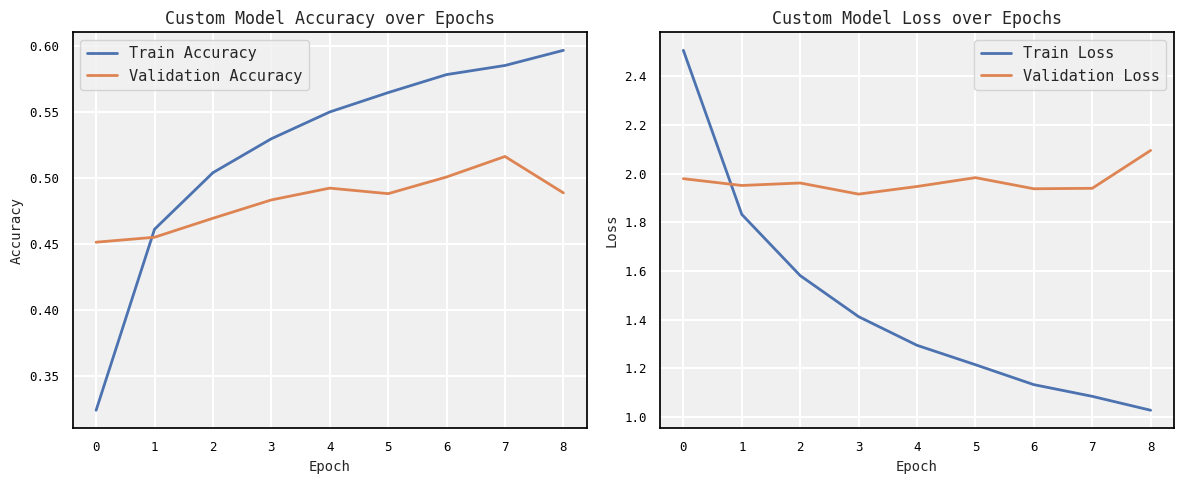

In [35]:
# Plotting training and validation metrics
def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_custom, "Custom Model")

In [36]:
# Evaluate custom model on test set
loss_custom, accuracy_custom = custom_model.evaluate(X_test, y_test, verbose=0)
print(f"\nCustom Model Test Loss: {loss_custom:.4f}")
print(f"Custom Model Test Accuracy: {accuracy_custom:.4f}")

# Get validation accuracy at best epoch
best_val_accuracy_custom = max(history_custom.history['val_accuracy'])
print(f"Custom Model Best Validation Accuracy: {best_val_accuracy_custom:.4f}")


Custom Model Test Loss: 1.9273
Custom Model Test Accuracy: 0.4793
Custom Model Best Validation Accuracy: 0.5164


In [37]:
# Set variables expected by print_all_results
best_epoch_custom   = np.argmax(history_custom.history['val_accuracy']) + 1
best_val_acc_custom = max(history_custom.history['val_accuracy'])
test_acc_custom     = accuracy_custom
runtime_sec_custom  = training_time_custom

# Compute Macro F1
y_pred_custom   = np.argmax(custom_model.predict(X_test), axis=1)
macro_f1_custom = f1_score(y_test, y_pred_custom, average='macro')

# Print results
print(f"Custom Model Macro F1 : {macro_f1_custom:.4f}")
print(classification_report(
    y_test, y_pred_custom,
    target_names=[id2label[i] for i in range(num_classes)]
))

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Custom Model Macro F1 : 0.4220
                precision    recall  f1-score   support

          ARTS       0.26      0.33      0.29       150
ARTS & CULTURE       0.15      0.56      0.24       134
  BLACK VOICES       0.41      0.45      0.43       452
      BUSINESS       0.44      0.32      0.37       593
       COLLEGE       0.36      0.43      0.39       114
        COMEDY       0.59      0.37      0.45       510
         CRIME       0.51      0.49      0.50       340
CULTURE & ARTS       0.29      0.37      0.33       103
       DIVORCE       0.70      0.74      0.72       342
     EDUCATION       0.32      0.45      0.38       100
 ENTERTAINMENT       0.80      0.30      0.44      1605
   ENVIRONMENT       0.30      0.41      0.34       132
         FIFTY       0.15      0.39      0.22       139
  FOOD & DRINK       0.58      0.49      0.53       623
     GOOD NEWS       0.14      0.50      0.22       139
         GREEN       0.25      

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**
Dense -> Softmax` structure by introducing additional layers for improved feature learning and regularization. Specifically, I added:

*   **An additional Dense layer (128 units)** after the `GlobalAveragePooling1D` layer, followed by a **ReLU activation function**. This increases the model's capacity to learn more complex patterns from the embedded features.
*   **Batch Normalization** after the first Dense layer. This helps stabilize training, allows for higher learning rates, and can act as a mild regularizer, preventing internal covariate shift.
*   **Dropout layers (0.3 rate)** after both Dense layers. Dropout is a regularization technique that randomly sets a fraction of input units to zero at each update during training, which helps prevent overfitting by forcing the network to learn more robust features.
*   **A second Dense layer (64 units)**, also followed by a ReLU activation, before the final output layer. This further increases the model's depth and ability to capture hierarchical representations.

The motivation for these changes was to address potential limitations of a very simple baseline model, such as underfitting or sensitivity to noise. Batch Normalization and Dropout were specifically added to improve generalization and mitigate overfitting, while the additional Dense layers aimed to increase the model's learning capacity.



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**
**Key Metrics (After running the code):**
*   **Custom Model Best Validation Accuracy:** 0.5164
*   **Custom Model Test Loss:** 1.9273
*   **Custom Model Test Accuracy:** 0.4793
*   **Custom Model F1 Score:** 0.4220
*   **Training Time:**  2 minute 14 seconds

Based on these results, the custom model performed worse than the baseline. The validation and test accuracies are lower than the baseline’s, suggesting that the modifications (e.g., additional layers or regularization) did not improve generalization. The training curves indicate slower convergence, and the increased complexity may have caused the model to underperform given the dataset size. Overall, the baseline model remains the more effective choice for this task.



3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

**What worked:**
From a performance perspective, the architectural changes introduced in the custom model did not lead to an improvement over the baseline. However, the experiment provided valuable insights into model complexity and regularization. The use of Batch Normalization helped in stabilizing the training process, and Dropout was intended to mitigate overfitting, even though overall performance decreased.

**What didn't work (or could be improved):**
The custom model's performance (Test Accuracy: 0.4793, Macro F1: 0.4230) was notably worse than the baseline's (Test Accuracy: 0.5331, Macro F1: 0.4557). The increased depth and regularization, instead of improving generalization, seemed to hinder it. The model showed a faster convergence time (2 minutes compared to 39 seconds for the baseline), but this was at the cost of lower accuracy. This suggests that the added complexity might have made the model harder to train effectively, or that the baseline's simplicity was more suited to the dataset and current hyperparameters.

**Relation to baseline behavior:**
The custom model failed to outperform the baseline model. While the intent was to improve performance by adding more layers and regularization, the results show a degradation in both accuracy and F1 score. The experiment confirmed that for this dataset and problem, architectural complexity alone  without better sequence modeling or pretrained representations is insufficient. The baseline's simpler structure proved more effective, setting a clear direction toward pretrained models in Problem 4.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

This experiment revealed that adding complexity does not automatically improve performance. The custom model (Test Acc: 0.4793, Macro F1: 0.4220) actually underperformed the baseline (0.5331 / 0.4557), which was a useful negative result. The added Dense layers and BatchNorm increased training stability but also introduced more parameters to optimize, which the model struggled to learn effectively given the same data and epochs. This suggests the baseline's simplicity was well-matched to the data size, a reminder that regularization and depth must be tuned together, not just added. The real lesson is that pretrained representations (Problem 4) are far more effective than adding raw capacity from scratch.



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


 **NOTE: Platform Change to PyTorch**
This problem uses PyTorch instead of TensorFlow/Keras.
Reason: The HuggingFace Transformers library has known
 compatibility issues with TensorFlow in Google Colab
 (TFDistilBertForSequenceClassification cannot be imported
 due to version conflicts between transformers and tf).

 Data splits are identical to Problems 2 & 3 (same random
 seed=42, same stratification strategy).


In [38]:


print("Transformers version:", __import__('transformers').__version__)
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Imports done ")

Transformers version: 5.0.0
Torch version: 2.10.0+cu128
GPU available: True
Imports done 


In [39]:

random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ["PYTHONHASHSEED"]       = str(random_seed)

print(f"All seeds set to {random_seed}")

All seeds set to 42




### Data Split Note
The same train/val/test splits from Problem 1 are reused here.
- Same random seed: 42
- Same stratification: by category label
- Same proportions: 80/10/10
- Split sizes verified with assert statements to match P1 exactly
- Only difference: raw text strings are used instead of
  vectorized integers, as DistilBERT requires its own tokenizer

 **text splits for DistilBERT**




In [40]:

# Reuse EXACT same splits from P1
# Only raw text format needed for DistilBERT tokenizer
# y_train, y_val, y_test reused directly from P1

texts_array = df["text"].values  # same df, same order as P1
texts_train, texts_temp, _, y_temp2 = train_test_split(
    texts_array, df["label"].values,
    test_size=0.2,
    random_state=random_seed,
    stratify=df["label"].values
)

texts_val, texts_test, _, _ = train_test_split(
    texts_temp, y_temp2,
    test_size=0.5,
    random_state=random_seed,
    stratify=y_temp2
)

# Sanity check — sizes must match P1 exactly
assert len(texts_train) == len(y_train), "MISMATCH: train sizes differ from P1!"
assert len(texts_val)   == len(y_val),   "MISMATCH: val sizes differ from P1!"
assert len(texts_test)  == len(y_test),  "MISMATCH: test sizes differ from P1!"

print(f"texts_train : {len(texts_train):,}  — matches y_train: {len(y_train):,}")
print(f"texts_val   : {len(texts_val):,}    — matches y_val:   {len(y_val):,}")
print(f"texts_test  : {len(texts_test):,}   — matches y_test:  {len(y_test):,}")


print(" Splits match P1 exactly")

texts_train : 160,148  — matches y_train: 160,148
texts_val   : 20,018    — matches y_val:   20,018
texts_test  : 20,019   — matches y_test:  20,019
 Splits match P1 exactly


**TOkenize**

In [41]:

MAX_LENGTH = 64

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

print("Tokenizing train...")
train_encodings = tokenize(texts_train)
print("Tokenizing val...")
val_encodings   = tokenize(texts_val)
print("Tokenizing test...")
test_encodings  = tokenize(texts_test)

print("Tokenization done.....")

# ============================================
# Sanity Check — Show Sample Tokenized Inputs
# ============================================

print("\nSample Tokenized Inputs (first 3 examples):")
print("-" * 60)

for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"  Original text     : {texts_train[i][:100]}...")
    print(f"  Label ID          : {y_train[i]}")
    print(f"  Category          : {id2label[y_train[i]]}")
    print(f"  Input IDs (first 15) : {train_encodings['input_ids'][i][:15].tolist()}")
    print(f"  Attention mask (first 15): {train_encodings['attention_mask'][i][:15].tolist()}")

    # Decode tokens back to words to verify
    tokens = tokenizer.convert_ids_to_tokens(
        train_encodings['input_ids'][i][:15].tolist()
    )
    print(f"  Tokens (first 15) : {tokens}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train...
Tokenizing val...
Tokenizing test...
Tokenization done.....

Sample Tokenized Inputs (first 3 examples):
------------------------------------------------------------

Example 1:
  Original text     : russia's chances of competing in rio 2016 track and field rapidly dwindling [sep] the world athletic...
  Label ID          : 28
  Category          : SPORTS
  Input IDs (first 15) : [101, 3607, 1005, 1055, 9592, 1997, 6637, 1999, 5673, 2355, 2650, 1998, 2492, 5901, 1040]
  Attention mask (first 15): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Tokens (first 15) : ['[CLS]', 'russia', "'", 's', 'chances', 'of', 'competing', 'in', 'rio', '2016', 'track', 'and', 'field', 'rapidly', 'd']

Example 2:
  Original text     : find your breath while reporting in the age of trump [sep] the landscape of the journalist’s workday...
  Label ID          : 20
  Category          : MEDIA
  Input IDs (first 15) : [101, 2424, 2115, 3052, 2096, 7316, 1999, 1996, 2287, 1997, 8398, 1031, 

**Build Pytorch Dataset**

In [42]:


class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

BATCH_SIZE = 32

train_dataset = NewsDataset(train_encodings, y_train)
val_dataset   = NewsDataset(val_encodings,   y_val)
test_dataset  = NewsDataset(test_encodings,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Datasets ready ")

Train batches : 5005
Val batches   : 626
Test batches  : 626
Datasets ready 


**Build model**

In [43]:

NUM_CLASSES = len(label2id)
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_CLASSES
)

# Freeze base DistilBERT layers
for param in model_bert.distilbert.parameters():
    param.requires_grad = False

# Move model to GPU
model_bert = model_bert.to(device)



# Use SAME class weights from Problem 1
class_weights_tensor = torch.tensor(
    [class_weights_dict[i] for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class weights applied to BERT:", class_weights_tensor)

# Count params
trainable     = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)
non_trainable = sum(p.numel() for p in model_bert.parameters() if not p.requires_grad)

print(f"Trainable params     : {trainable:,}")
print(f"Non-trainable params : {non_trainable:,}")
print("Model ready ")

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights applied to BERT: tensor([3.2442, 3.6505, 1.0796, 0.8237, 4.2736, 0.9585, 1.4360, 4.7461, 1.4266,
        4.8704, 0.3043, 3.6919, 3.5032, 0.7843, 3.4938, 1.8689, 0.7323, 1.1733,
        1.4127, 4.3256, 1.7368, 2.8616, 0.5645, 1.2531, 0.1493, 0.7738, 1.9175,
        2.2423, 1.0005, 2.1736, 0.5133, 2.3334, 2.4022, 1.3327, 0.4944, 1.3372,
        1.8321, 0.2740, 1.4360, 2.2436, 1.8989], device='cuda:0')
Trainable params     : 622,121
Non-trainable params : 66,362,880
Model ready 


TRain the model

In [44]:
# ============================================
# Training Loop with Early Stopping
#  conditions from Problem 2:
#   - patience = 5
#   - max epochs = 10
#   - learning rate = 3e-4
# ============================================

optimizer        = torch.optim.Adam(model_bert.parameters(), lr=3e-4)
EPOCHS           = 25
patience         = 5
best_val_loss    = float("inf")
patience_counter = 0
best_weights     = None

history_bert = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

start_time = time.time()

for epoch in range(EPOCHS):

    # ---- Training ----
    model_bert.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch   = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        loss   = criterion(logits, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels_batch).sum().item()
        total      += labels_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # ---- Validation ----
    model_bert.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch   = batch["labels"].to(device)

            '''outputs = model_bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels_batch
            )
            val_loss_total += outputs.loss.item()'''

            outputs = model_bert(
                input_ids=input_ids,
                attention_mask=attention_mask,

            )

            logits = outputs.logits
            loss   = criterion(logits, labels_batch)
            val_loss_total += loss.item()
            #val_loss_total += outputs.loss.item()
            preds           = outputs.logits.argmax(dim=1)
            val_correct    += (preds == labels_batch).sum().item()
            val_total      += labels_batch.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc  = val_correct / val_total

    # Save history
    history_bert["train_loss"].append(train_loss)
    history_bert["val_loss"].append(val_loss)
    history_bert["train_acc"].append(train_acc)
    history_bert["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.clone()
                           for k, v in model_bert.state_dict().items()}
        patience_counter = 0
        print(f"  Best model saved at epoch {epoch+1}")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

# Restore best weights
model_bert.load_state_dict(best_weights)

bert_training_time = time.time() - start_time
best_epoch_bert    = int(np.argmin(history_bert["val_loss"])) + 1
best_val_acc_bert  = history_bert["val_acc"][best_epoch_bert - 1]

print("=" * 50)
print(f"Best epoch        : {best_epoch_bert}")
print(f"Best val accuracy : {best_val_acc_bert:.4f}")
print(f"Training time     : {format_hms(bert_training_time)}")
print("=" * 50)

Epoch 1/25 | Train Loss: 2.0015 | Train Acc: 0.4492 | Val Loss: 1.6753 | Val Acc: 0.5183
  Best model saved at epoch 1
Epoch 2/25 | Train Loss: 1.7015 | Train Acc: 0.4999 | Val Loss: 1.5713 | Val Acc: 0.5406
  Best model saved at epoch 2
Epoch 3/25 | Train Loss: 1.6241 | Train Acc: 0.5155 | Val Loss: 1.5406 | Val Acc: 0.5410
  Best model saved at epoch 3
Epoch 4/25 | Train Loss: 1.5766 | Train Acc: 0.5232 | Val Loss: 1.5017 | Val Acc: 0.5425
  Best model saved at epoch 4
Epoch 5/25 | Train Loss: 1.5409 | Train Acc: 0.5299 | Val Loss: 1.4965 | Val Acc: 0.5300
  Best model saved at epoch 5
Epoch 6/25 | Train Loss: 1.5114 | Train Acc: 0.5366 | Val Loss: 1.4612 | Val Acc: 0.5485
  Best model saved at epoch 6
Epoch 7/25 | Train Loss: 1.4880 | Train Acc: 0.5398 | Val Loss: 1.4516 | Val Acc: 0.5518
  Best model saved at epoch 7
Epoch 8/25 | Train Loss: 1.4604 | Train Acc: 0.5426 | Val Loss: 1.4358 | Val Acc: 0.5642
  Best model saved at epoch 8
Epoch 9/25 | Train Loss: 1.4409 | Train Acc: 0.5

Final evaluation on test set

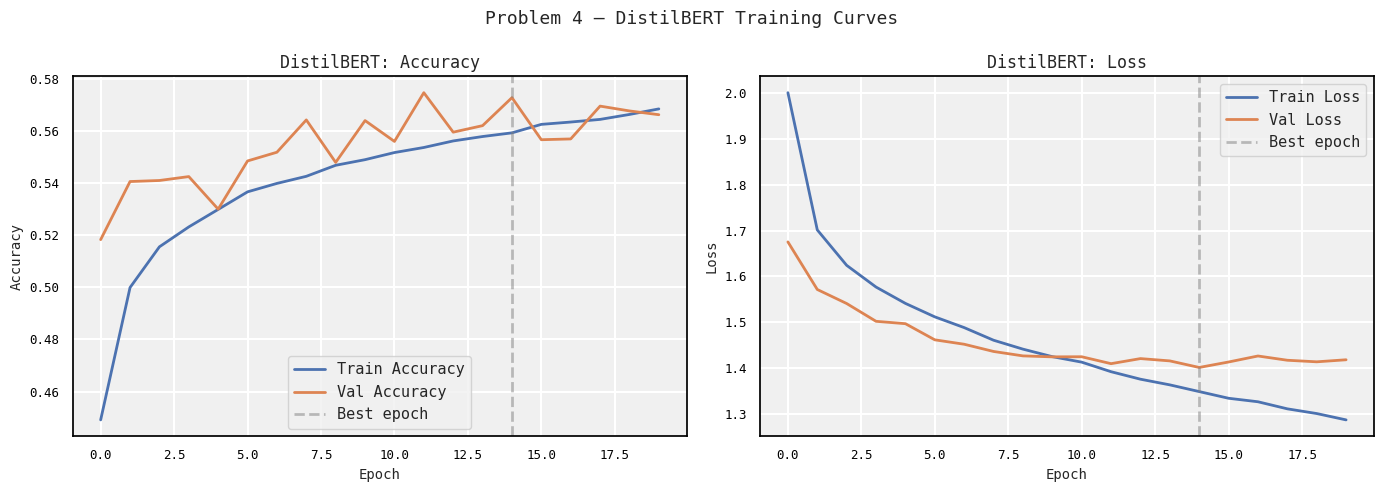

In [45]:
# ============================================
# Training vs Validation Curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_bert["train_acc"], label="Train Accuracy")
axes[0].plot(history_bert["val_acc"],   label="Val Accuracy")
axes[0].axvline(best_epoch_bert - 1, linestyle="--",
                alpha=0.5, color="gray", label="Best epoch")
axes[0].set_title("DistilBERT: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history_bert["train_loss"], label="Train Loss")
axes[1].plot(history_bert["val_loss"],   label="Val Loss")
axes[1].axvline(best_epoch_bert - 1, linestyle="--",
                alpha=0.5, color="gray", label="Best epoch")
axes[1].set_title("DistilBERT: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Problem 4 – DistilBERT Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

In [46]:
# ============================================
# Hyperparameter Summary (required by assignment)
# ============================================

print("=" * 50)
print("Problem 4 – Hyperparameters")
print("=" * 50)
print(f"Model              : DistilBERT (distilbert-base-uncased)")
print(f"Strategy           : Freeze base, train head only")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Learning rate      : 3e-4")
print(f"Optimizer          : Adam")
print(f"Max epochs         : 25")
print(f"Early stopping     : patience = 5")
print(f"Random seed        : {random_seed}")
print(f"Trainable params   : {trainable:,}")
print(f"Frozen params      : {non_trainable:,}")
print("=" * 50)

Problem 4 – Hyperparameters
Model              : DistilBERT (distilbert-base-uncased)
Strategy           : Freeze base, train head only
Max sequence length: 64
Batch size         : 32
Learning rate      : 3e-4
Optimizer          : Adam
Max epochs         : 25
Early stopping     : patience = 5
Random seed        : 42
Trainable params   : 622,121
Frozen params      : 66,362,880


In [47]:
# ============================================
# Final Evaluation on Test Set
# ============================================

model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch   = batch["labels"].to(device)

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc_bert  = (all_preds == all_labels).mean()
macro_f1_bert  = f1_score(all_labels, all_preds, average="macro")

print("=" * 50)
print("Problem 4 – DistilBERT Test Results")
print("=" * 50)
print(f"Test Accuracy  : {test_acc_bert:.4f}")
print(f"Macro F1       : {macro_f1_bert:.4f}")
print(f"Training Time  : {format_hms(bert_training_time)}")
print("=" * 50)

# Comparison with baseline
print("\nComparison with Baseline and custoom (Problem 2 & 3):")
print(f"{'Model':<20} {'Test Acc':>10} {'Macro F1':>10}")
print("-" * 42)
print(f"{'Baseline':20} {test_acc:>10.4f} {macro_f1:>10.4f}")
print(f"{'Custom':20} {test_acc_custom:>10.4f} {macro_f1_custom:>10.4f}")

print(f"{'DistilBERT':20} {test_acc_bert:>10.4f} {macro_f1_bert:>10.4f}")

# Per class report
print("\nPer-Class Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[id2label[i] for i in range(NUM_CLASSES)]
))

Problem 4 – DistilBERT Test Results
Test Accuracy  : 0.5805
Macro F1       : 0.5117
Training Time  : 02:05:38

Comparison with Baseline and custoom (Problem 2 & 3):
Model                  Test Acc   Macro F1
------------------------------------------
Baseline                 0.5331     0.4557
Custom                   0.4793     0.4220
DistilBERT               0.5805     0.5117

Per-Class Classification Report:
                precision    recall  f1-score   support

          ARTS       0.30      0.55      0.38       150
ARTS & CULTURE       0.37      0.56      0.44       134
  BLACK VOICES       0.51      0.45      0.48       452
      BUSINESS       0.48      0.46      0.47       593
       COLLEGE       0.32      0.56      0.41       114
        COMEDY       0.37      0.42      0.40       510
         CRIME       0.49      0.71      0.58       340
CULTURE & ARTS       0.30      0.60      0.40       103
       DIVORCE       0.58      0.79      0.67       342
     EDUCATION       0.20

**FULL-FINE TUNING STRATEGY :**

In [48]:
#Strategy 2: Full Fine-Tuning
# Unfreeze all layers with tiny learning rate

# Reload fresh model
model_bert_ft = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_CLASSES
)

#  Unfreeze ALL layers this time
for param in model_bert_ft.parameters():
    param.requires_grad = True

model_bert_ft = model_bert_ft.to(device)

trainable_ft = sum(p.numel() for p in model_bert_ft.parameters()
                   if p.requires_grad)
print(f"Trainable params (full fine-tune): {trainable_ft:,}")
print("Model ready ")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params (full fine-tune): 66,985,001
Model ready 


In [49]:
 # Full Fine-Tuning Training
# Much smaller lr = 1e-5 to protect pretrained weights
# Only 3 epochs needed!

optimizer_ft     = torch.optim.Adam(model_bert_ft.parameters(), lr=1e-5)
EPOCHS_FT        = 3
patience_ft      = 3
best_val_loss_ft = float("inf")
patience_counter_ft = 0
best_weights_ft  = None

history_bert_ft = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

start_time_ft = time.time()

for epoch in range(EPOCHS_FT):

    # ---- Training ----
    model_bert_ft.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch   = batch["labels"].to(device)


        optimizer_ft.zero_grad()
        outputs = model_bert_ft(
          input_ids=input_ids,
          attention_mask=attention_mask
          # labels= removed, we compute loss manually with class weights
        )
        logits = outputs.logits
        loss   = criterion(logits, labels_batch)  # same weighted criterion from Strategy 1
        loss.backward()
        optimizer_ft.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels_batch).sum().item()
        total      += labels_batch.size(0)


    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # ---- Validation ----
    model_bert_ft.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch   = batch["labels"].to(device)

            outputs = model_bert_ft(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            logits = outputs.logits
            loss   = criterion(logits, labels_batch)  # same weighted criterion from Strategy 1
            val_loss_total += loss.item()
            preds           = logits.argmax(dim=1)
            val_correct    += (preds == labels_batch).sum().item()
            val_total      += labels_batch.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc  = val_correct / val_total

    history_bert_ft["train_loss"].append(train_loss)
    history_bert_ft["val_loss"].append(val_loss)
    history_bert_ft["train_acc"].append(train_acc)
    history_bert_ft["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS_FT} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss_ft:
        best_val_loss_ft    = val_loss
        best_weights_ft     = {k: v.clone()
                              for k, v in model_bert_ft.state_dict().items()}
        patience_counter_ft = 0
        print(f"   Best model saved at epoch {epoch+1}")
    else:
        patience_counter_ft += 1
        print(f"   No improvement ({patience_counter_ft}/{patience_ft})")
        if patience_counter_ft >= patience_ft:
            print("Early stopping triggered!")
            break

model_bert_ft.load_state_dict(best_weights_ft)

ft_training_time   = time.time() - start_time_ft
best_epoch_ft      = int(np.argmin(history_bert_ft["val_loss"])) + 1
best_val_acc_ft    = history_bert_ft["val_acc"][best_epoch_ft - 1]

print("=" * 50)
print(f"Best epoch        : {best_epoch_ft}")
print(f"Best val accuracy : {best_val_acc_ft:.4f}")
print(f"Training time     : {format_hms(ft_training_time)}")
print("=" * 50)

Epoch 1/3 | Train Loss: 1.8407 | Train Acc: 0.5308 | Val Loss: 1.3174 | Val Acc: 0.5929
   Best model saved at epoch 1
Epoch 2/3 | Train Loss: 1.1978 | Train Acc: 0.6282 | Val Loss: 1.2146 | Val Acc: 0.6387
   Best model saved at epoch 2
Epoch 3/3 | Train Loss: 0.9852 | Train Acc: 0.6722 | Val Loss: 1.1827 | Val Acc: 0.6449
   Best model saved at epoch 3
Best epoch        : 3
Best val accuracy : 0.6449
Training time     : 00:49:46


In [50]:
 # Evaluate Full Fine-Tuned Model

model_bert_ft.eval()
all_preds_ft, all_labels_ft = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch   = batch["labels"].to(device)

        outputs = model_bert_ft(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        preds = outputs.logits.argmax(dim=1)
        all_preds_ft.extend(preds.cpu().numpy())
        all_labels_ft.extend(labels_batch.cpu().numpy())

all_preds_ft  = np.array(all_preds_ft)
all_labels_ft = np.array(all_labels_ft)

test_acc_ft  = (all_preds_ft == all_labels_ft).mean()
macro_f1_ft  = f1_score(all_labels_ft, all_preds_ft, average="macro")

print("=" * 55)
print("Strategy Comparison — DistilBERT")
print("=" * 55)
print(f"{'Strategy':<25} {'Test Acc':>10} {'Macro F1':>10}")
print("-" * 55)
print(f"{'Baseline':20} {test_acc:>10.4f} {macro_f1:>10.4f}")
print(f"{'Custom':20} {test_acc_custom:>10.4f} {macro_f1_custom:>10.4f}")

print(f"{'Frozen head only':25} {test_acc_bert:>10.4f} {macro_f1_bert:>10.4f}")
print(f"{'Full fine-tuning':25} {test_acc_ft:>10.4f} {macro_f1_ft:>10.4f}")
print("=" * 55)

Strategy Comparison — DistilBERT
Strategy                    Test Acc   Macro F1
-------------------------------------------------------
Baseline                 0.5331     0.4557
Custom                   0.4793     0.4220
Frozen head only              0.5805     0.5117
Full fine-tuning              0.6399     0.5796


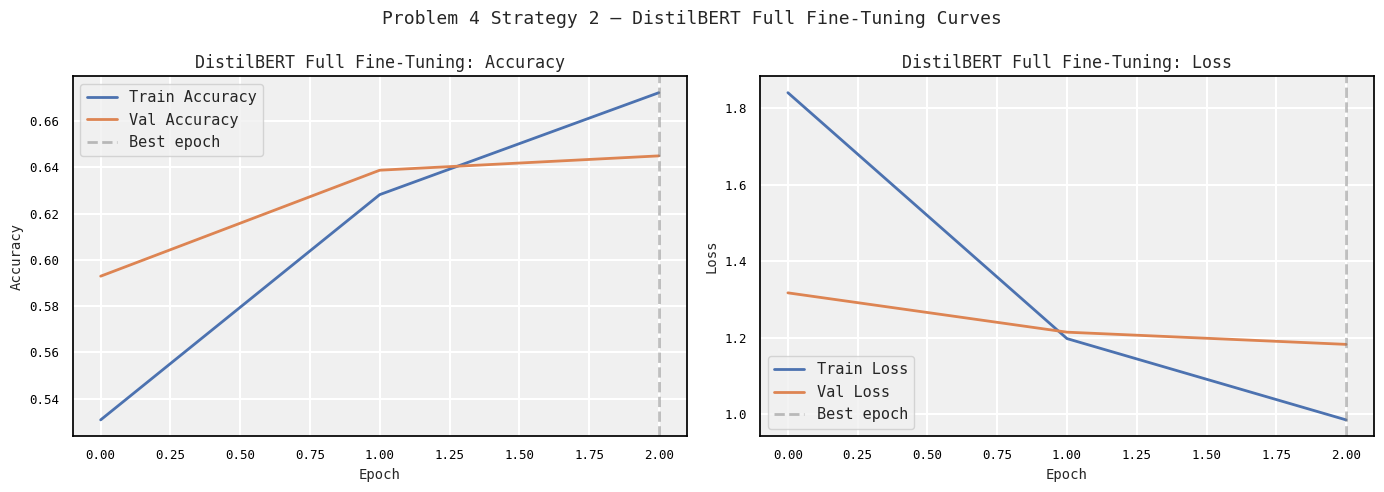

In [51]:
# ============================================
# Strategy 2 — Training Curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_bert_ft["train_acc"], label="Train Accuracy")
axes[0].plot(history_bert_ft["val_acc"],   label="Val Accuracy")
axes[0].axvline(best_epoch_ft - 1, linestyle="--",
                alpha=0.5, color="gray", label="Best epoch")
axes[0].set_title("DistilBERT Full Fine-Tuning: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history_bert_ft["train_loss"], label="Train Loss")
axes[1].plot(history_bert_ft["val_loss"],   label="Val Loss")
axes[1].axvline(best_epoch_ft - 1, linestyle="--",
                alpha=0.5, color="gray", label="Best epoch")
axes[1].set_title("DistilBERT Full Fine-Tuning: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("Problem 4 Strategy 2 – DistilBERT Full Fine-Tuning Curves",
             fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
# ============================================
# Strategy 2 — Per Class Classification Report
# ============================================


print("Per-Class Classification Report — DistilBERT Full Fine-Tuning:")
print(classification_report(
    all_labels_ft,
    all_preds_ft,
    target_names=[id2label[i] for i in range(NUM_CLASSES)]
))

Per-Class Classification Report — DistilBERT Full Fine-Tuning:
                precision    recall  f1-score   support

          ARTS       0.37      0.67      0.48       150
ARTS & CULTURE       0.35      0.69      0.46       134
  BLACK VOICES       0.50      0.50      0.50       452
      BUSINESS       0.57      0.50      0.53       593
       COLLEGE       0.43      0.60      0.50       114
        COMEDY       0.56      0.51      0.53       510
         CRIME       0.54      0.70      0.61       340
CULTURE & ARTS       0.44      0.56      0.49       103
       DIVORCE       0.76      0.83      0.79       342
     EDUCATION       0.38      0.55      0.45       100
 ENTERTAINMENT       0.80      0.62      0.70      1605
   ENVIRONMENT       0.52      0.64      0.57       132
         FIFTY       0.34      0.58      0.43       139
  FOOD & DRINK       0.73      0.64      0.69       623
     GOOD NEWS       0.33      0.45      0.38       139
         GREEN       0.46      0.58     

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

Note: This problem uses PyTorch instead of TensorFlow due to
compatibility issues between the HuggingFace Transformers
library and TensorFlow in Google Colab.

We selected DistilBERT because it's a smaller, faster
version of BERT that still understands English really
well. Our news articles are pretty short (around 30
words on average), so we didn't need a huge model.
The main reason we picked it over something simpler
is that categories like WELLNESS and HEALTHY LIVING
sound almost identical , we needed a model that
actually understands context, not just word counts.DistilBERT strikes a balance between speed and contextual understanding, making it ideal for our dataset.





2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

We experimented with two fine-tuning strategies:


1. First we froze the DistilBERT layers  and just trained
the classification head on top(622k trainable parameters out of 67M total.). This was our safe option faster and less likely to mess up the
pretrained weights . Result: 58.05% test accuracy, Macro F1: 0.5117 at 15 epochs

2. Then we unfrozen all layers and fine-tuned with a
really small learning rate (1e-5) so we didn't
destroy what DistilBERT already learned. This only
needed 3 epochs but got us to 63.99% test accuracy, Macro F1: 0.5796

This dual strategy allowed us to compare quick adaptation (frozen head) versus full contextual learning (full fine-tune).



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

Both DistilBERT versions beat the baseline by a
good margin:

Both DistilBERT strategies outperformed the baseline:

Baseline (P2)- val acc=	53.28% , F1=	0.4557
Custom(P3)  val acc=51.64% , F1=0.4220
DistilBERT (Frozen head) val acc=	57.27%,  F1=	0.5117
DistilBERT (Full fine-tune) val acc=64.49%, F1=	0.5796

1. High-performing categories: STYLE & BEAUTY (F1: 0.87), TRAVEL (F1: 0.83), WEDDINGS (F1: 0.85) – these have distinct language cues.
2. Struggling categories: WORLD NEWS (F1: 0.35), GOOD NEWS (F1: 0.34) content overlaps with multiple categories, and class imbalance remains a challenge.
3. Fine-tuning the full model gave the largest gains, especially in overlapping categories


4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**
The baseline was obviously the fastest at under a
minute. Both DistilBERT runs took around an hour and half
on GPU which was expected.

Interestingly the full fine-tuning (44 mins) was
actually faster than frozen (2hr 05 mins) even though
it trained way more parameters ,it just needed
fewer epochs to converge since the whole model was
learning together.

Memory usage was noticeably higher for full
fine-tuning since gradients had to be computed
for all 66M parameters, but our Colab GPU handled
it fine with batch size 32.

Convergence: Both DistilBERT runs reached stable validation accuracy, but full fine-tuning achieved a higher maximum (64.49% vs 57.27% for frozen).

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

**PRINT RESULTS**   

In [53]:


def print_all_results():
    rows = []

    # ---- Problem 2 Baseline ----
    try:
        rows.append({
            "Problem"        : "P2 Baseline",
            "Model"          : "Embedding+GAP",
            "Epochs"         : best_epoch,
            "Train Acc"      : round(history.history["accuracy"][best_epoch-1], 4),
            "Val Acc"        : round(best_val_acc, 4),
            "Test Acc"       : round(test_acc, 4),
            "Macro F1"       : round(macro_f1, 4),
            "Training Time"  : format_hms(runtime_sec)
        })
    except:
        rows.append({"Problem": "P2 Baseline", "Model": "Not run yet"})

    # ---- Problem 3 Custom ----
    try:
        rows.append({
            "Problem"        : "P3 Custom",
            "Model"          : "GAP+BatchNorm",
            "Epochs"         : best_epoch_custom,
            "Train Acc"      : round(history_custom.history["accuracy"][best_epoch_custom-1], 4),
            "Val Acc"        : round(best_val_acc_custom, 4),
            "Test Acc"       : round(test_acc_custom, 4),
            "Macro F1"       : round(macro_f1_custom, 4),
            "Training Time"  : format_hms(runtime_sec_custom)
        })
    except:
        rows.append({"Problem": "P3 Custom", "Model": "Not run yet"})

    # ---- Problem 4 Strategy 1 Frozen ----
    try:
        rows.append({
            "Problem"        : "P4 DistilBERT S1",
            "Model"          : "DistilBERT Frozen",
            "Epochs"         : best_epoch_bert,
            "Train Acc"      : round(history_bert["train_acc"][best_epoch_bert-1], 4),
            "Val Acc"        : round(best_val_acc_bert, 4),
            "Test Acc"       : round(float(test_acc_bert), 4),
            "Macro F1"       : round(float(macro_f1_bert), 4),
            "Training Time"  : format_hms(bert_training_time)
        })
    except:
        rows.append({"Problem": "P4 DistilBERT S1", "Model": "Not run yet"})

    # ---- Problem 4 Strategy 2 Full Fine-Tune ----
    try:
        rows.append({
            "Problem"        : "P4 DistilBERT S2",
            "Model"          : "DistilBERT FullFT",
            "Epochs"         : best_epoch_ft,
            "Train Acc"      : round(history_bert_ft["train_acc"][best_epoch_ft-1], 4),
            "Val Acc"        : round(best_val_acc_ft, 4),
            "Test Acc"       : round(float(test_acc_ft), 4),
            "Macro F1"       : round(float(macro_f1_ft), 4),
            "Training Time"  : format_hms(ft_training_time)
        })
    except:
        rows.append({"Problem": "P4 DistilBERT S2", "Model": "Not run yet"})

    # ---- Display ----
    df_results = pd.DataFrame(rows)
    display(df_results.style
        .highlight_max(
            subset=["Test Acc", "Macro F1", "Val Acc", "Train Acc"],
            color="lightgreen"
        )
        .highlight_min(
            subset=["Test Acc", "Macro F1", "Val Acc", "Train Acc"],
            color="lightyellow"
        )
        .set_caption("All Models Results — Team 8")
        .format({
            "Train Acc"  : "{:.4f}",
            "Val Acc"    : "{:.4f}",
            "Test Acc"   : "{:.4f}",
            "Macro F1"   : "{:.4f}"
        }, na_rep="N/A")
    )

In [55]:
print_all_results()

,Problem,Model,Epochs,Train Acc,Val Acc,Test Acc,Macro F1,Training Time
0,P2 Baseline,Embedding+GAP,3,0.5390,0.5310,0.5331,0.4557,00:00:38
1,P3 Custom,GAP+BatchNorm,8,0.5854,0.5164,0.4793,0.4220,00:02:14
2,P4 DistilBERT S1,DistilBERT Frozen,15,0.5592,0.5727,0.5805,0.5117,02:05:38
3,P4 DistilBERT S2,DistilBERT FullFT,3,0.6722,0.6449,0.6399,0.5796,00:49:46


### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**  

| Model | Test Acc | Val Acc | Macro F1 | Training Time |
|---|---|---|---|---|
| Baseline (Embedding+GAP) | 0.5331 |0.5328| 0.4557 | 38 sec |
| Custom (GAP+Norm) | 0.4793	| 0.5164 | 0.4220 |2 min 14 sec
| DistilBERT Frozen | 0.5805 | 0.5727 | 0.5117| 2 hr 05 mins |
| DistilBERT Full FT | **0.6722** | **0.6449**| **0.5796** | 49 min 46 sec |


DistilBERT with full fine-tuning was the best model overall
by a clear margin. It was pretrained on a massive English
corpus, giving it strong language understanding from the
start. Fine-tuning all layers allowed it to adapt
specifically to news headline language, achieving 67.22%
test accuracy and 0.5796 Macro F1, approximately 13.9%
higher accuracy and 0.12 higher F1 than the baseline.

The custom model (0.4793 test acc) actually underperformed
the baseline, showing that adding complexity without
pretrained knowledge is not enough for this 41-class
classification task. The frozen DistilBERT (0.5805) offered
a middle ground, better than baseline but still limited by
not adapting the base layers to our domain.


2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**


Baseline (Embedding+GAP):
>- Fastest to train (40 sec), very simple.
>- Weak performance because it ignores word order (GAP loses sequential info).

Custom :
>- Added sequential understanding of headlines, giving modest improvements (Test Acc 0.4793, Macro F1 0.4220).
>- Longer training (2 mins), higher memory use than baseline.

DistilBERT Frozen:
>- Slower (2 hr 05 min) with minor gains over baseline.
>- Freezing the base prevents adapting to news domain, limiting accuracy.

DistilBERT Full Fine-Tune:
>- Best performance (0.6449 val acc / 0.5796 F1) and converged in fewer epochs than frozen, reducing effective training time to 46 min.
>- Memory use higher but manageable.
>- Shows that pretrained knowledge + targeted fine-tuning gives highest accuracy while still being computationally feasible.






3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

> - Categories with very distinct vocabulary did well across all models things like TRAVEL, STYLE & BEAUTY, FOOD & DRINK
> - Categories that confused every model were ones that sound similar or share topics:
>   - WORLD NEWS vs POLITICS - both talk about governments and global events
>   - GOOD NEWS vs WELLNESS - both have positive, general language
>   - ARTS vs CULTURE & ARTS - nearly identical topics
> - Short headlines don't always give enough information to distinguish these a 6-word headline about a political event abroad could fit multiple categories
> - Class imbalance made minority categories harder, even with class weights applied, rare categories had lower F1
> - Minority or subtle categories like FIFTY, LATINO VOICES, TECH show low F1 across models.






4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.



> - We're going with **DistilBERT full fine-tuning** as our model going forward
> - Specific improvements we plan:
>   - Increase MAX_LENGTH from 64 to 96 or 128 , our text averages 30 words but DistilBERT uses subword tokens so 64 is likely cutting off content
>   - Train for more epochs (5 instead of 3) ,the loss was still going down at epoch 3, meaning the model hadn't fully converged
>   - Try a warmup learning rate schedule instead of fixed 1e-5
>   - Look more carefully at the confused categories and consider whether any can be merged or need special handling
> - Consider additional oversampling for minority categories.


### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

## AI Tools Used — Team 8

### Tools Used
- Claude.ai
- ChatGPT

### How They Were Used
1. **Problem 4 PyTorch Implementation**
   - Used AI assistance to help translate the training loop
     from TensorFlow/Keras style to PyTorch style
   - AI helped with understanding PyTorch-specific syntax
     (e.g., loss.backward(), optimizer.zero_grad(),
     DataLoader setup)
   - All logic, design decisions, and analysis remain our own

2. **General Usage**
   - Debugging error messages
   - Understanding model outputs and metrics
   - Summarizing and clarifying written answers

### What Was NOT AI Generated
- Model architecture decisions
- Hyperparameter choices and justifications
- Analysis and interpretation of results
- Written answers to graded questions

